In [3]:
from scipy.optimize import root_scalar, root
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# from decimal import Decimal
# from math import isclose
import sys
sys.path.append('/home/christian/Documents/Praktikum/praktikum_env/')
import pandas as pd

import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
cm = 1/2.54  
width = 12*cm 

In [86]:
import numpy as np
import matplotlib.pyplot as plt

def multiple_formatter(denominator=2, number=np.pi, latex='\pi'):
    def gcd(a, b):
        while b:
            a, b = b, a%b
        return a
    def _multiple_formatter(x, pos):
        print('x: ',x,' pos: ',pos)
        den = denominator
        num = np.rint(den*x/number).astype(np.int64)
        com = gcd(num,den)
        (num,den) = (int(num/com),int(den/com))
        if den==1:
            if num==0:
                return r'$0$'
            if num==1:
                return r'$%s$'%latex
            elif num==-1:
                return r'$-%s$'%latex
            else:
                return r'$%s%s$'%(num,latex)
        else:
            if num==1:
                return r'$\frac{%s}{%s}$'%(latex,den)
            elif num==-1:
                return r'$\frac{-%s}{%s}$'%(latex,den)
            else:
                return r'$\frac{%s%s}{%s}$'%(num,latex,den)
    return _multiple_formatter

class Multiple:
    def __init__(self, denominator=2, number=np.pi, latex='\pi'):
        self.denominator = denominator
        self.number = number
        self.latex = latex

    def locator(self):
        return plt.MultipleLocator(self.number / self.denominator)

    def formatter(self):
        return plt.FuncFormatter(multiple_formatter(self.denominator, self.number, self.latex))

In [4]:
class TickProperties():
    
    major_xtick_step = 5,
    minor_xtick_step = 1
    major_ytick_step = 5
    minor_ytick_step = 1
    STRIP_OF_ZEROS_X = False
    STRIP_OF_ZEROS_Y = False

    def __init__(self,\
    xtick_step_major = 5,\
    xtick_step_minor = 1,\
    ytick_step_major = 5,\
    ytick_step_minor = 1,\
    SZX = False,\
    SZY = False):
        self.major_xtick_step = xtick_step_major
        self.minor_xtick_step = xtick_step_minor
        self.major_ytick_step = ytick_step_major
        self.minor_ytick_step = ytick_step_minor
        self.STRIP_OF_ZEROS_X = SZX
        self.STRIP_OF_ZEROS_Y = SZY

class Format():
    numb_xticks = None
    numb_yticks = None
    custom_func_x = None
    custom_func_y = None
    x_scale = None
    y_scale = None
    x_precion = "{:.2f}"
    y_precion = "{:.2f}"
    def __init__(self,numb_xticks=None,numb_yticks=None,custom_funx=None,custom_funy=None,xscale=None,yscale=None,xprec="{:.2f}",yprec="{:.2f}"):
        self.numb_xticks =numb_xticks
        self.numb_yticks = numb_yticks
        self.custom_func_x = custom_funx
        self.custom_func_y = custom_funy
        self.x_precion=xprec
        self.y_precion = yprec
        self.x_scale = xscale
        self.y_scale = yscale
    def formatx0(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            # print(x,pos,self.numb_xticks)
            index = int((pos-1)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print(self.x_precion.format(self.x_scale[index]))
            return self.x_precion.format(self.x_scale[index])
        except:
            return self.x_precion.format(self.x_scale[-1])
    def formatx1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            # print(pos)
            index = int((pos)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print()
            return self.x_precion.format(self.x_scale[index])
        except:
            return self.x_precion.format(self.x_scale[-1])
    
    def formaty1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))

            index = int((pos-1)*self.y_scale.shape[0]//self.numb_yticks)
            # print(index)
            # print()
            return self.y_precion.format(self.y_scale[index])
        except:
            return self.y_precion.format(self.y_scale[-1])
        
    def formaty(self,x,pos):
        try:
            return self.y_precion.format(self.y_scale[int(x)])
        except:
            return ""

class Setup_Fig():
    DEFAULT_HEAT_EXTEND = (-0.5,39.5,29.5,-0.5)
    xlim = None
    ylim = None
    tickprop = TickProperties()
    formatter = Format()
    cm = 1/2.54 
    fig_width = 12*cm
    fig_height = 4.8/6.4*12*cm
    name_of_plot = None
    def __init__(self,name_of_plot = "sign_of_ev1.pdf",xlim=None,ylim=None,tickp=TickProperties(),formater=Format()):
        self.xlim=xlim
        self.ylim = ylim   
        self.tickprop =tickp       
        self.formatter = formater
        self.name_of_plot = name_of_plot

    
    plt.rcParams["lines.markersize"]=0.7
    plt.rcParams["axes.unicode_minus"]=True
    plt.rcParams["font.size"]=10
    plt.rcParams["text.usetex"]=True
    plt.rcParams["font.serif"]="Computer Modern Serif"
# ax.scatter(A,root,color='0')
    



    def return_fig(self,shape=(1,1),dots_per_inch=400,xax_share=False,yax_share=False,joined=False,set_ticks=True,heightratio=None):
        if heightratio:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=xax_share,sharey=yax_share,height_ratios=heightratio)
        else:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=xax_share,sharey=yax_share)
        trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        self.formatter.numb_xticks = xw//self.tickprop.major_xtick_step
        self.formatter.numb_yticks = yw//self.tickprop.major_ytick_step
        
        for i in range(shape[0]):
            for j in range(shape[1]):
                pos= 'outer_left'
                if shape[0]==1:
                    if shape[1]==1:
                        current_ax = ax
                    else:
                        current_ax = ax[j]
                else:
                    if shape[1]==1:
                        current_ax = ax[i]
                    else:
                        current_ax = ax[i,j]
                        if j==0:
                           pos= 'outer_left'
                        elif j<shape[1]-1:
                            pos = 'middle'
                        elif j==shape[1]-1:
                            pos = 'outer_right'
                        


        # axlimits have to be adapted
                try:
                    current_ax.set_xlim(*self.xlim)
                except:
                    pass
                try:
                    current_ax.set_ylim(*self.ylim)
                except:
                    pass    
            
                if set_ticks:
                    if self.tickprop.STRIP_OF_ZEROS_X:
                        current_ax.xaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formatx0))
                    current_ax.yaxis.set_major_locator(ticker.MultipleLocator(self.tickprop.major_ytick_step))
                    current_ax.yaxis.set_minor_locator(ticker.MultipleLocator(self.tickprop.minor_ytick_step))
                    current_ax.xaxis.set_major_locator(ticker.MultipleLocator(self.tickprop.major_xtick_step))
                    current_ax.xaxis.set_minor_locator(ticker.MultipleLocator(self.tickprop.minor_xtick_step))

                    if self.tickprop.STRIP_OF_ZEROS_Y:
                        current_ax.yaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formaty1))  

                if joined:
                    if i<shape[0]-1:
                        current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=False)
                    else:
                        current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
                        
                    if pos=='outer_left':
                        current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)
                    elif pos=='middle':
                        current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=False)
                    elif pos=='outer_right':
                        current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelright=True)
                        # current_ax.set_xlabel(r'$\Gamma \tilde{A}$')
                        # current_ax.set_ylabel(r'$\tilde{y}$',rotation=0)
                else:
                    current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
                    
                    current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)   


                current_ax.tick_params(axis='both',which='major',length=4.5)
                plt.setp(current_ax.yaxis.get_majorticklabels(),va='center')
        
        return fig, ax


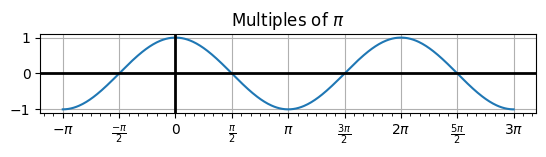

In [ ]:
x = np.linspace(-np.pi, 3*np.pi,500)
plt.plot(x, np.cos(x))
plt.title(r'Multiples of $\pi$')
ax[1] = plt.gca()
ax[1].grid(True)
ax[1].set_aspect(1.0)
ax[1].axhline(0, color='black', lw=2)
ax[1].axvline(0, color='black', lw=2)
ax[1].xaxis.set_major_locator(plt.MultipleLocator(np.pi / 2))
ax[1].xaxis.set_minor_locator(plt.MultipleLocator(np.pi / 12))
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(multiple_formatter()))
plt.show()


In [116]:
df = pd.read_csv('Reihen_analog_Chr_Matt.csv')
def zmode(R,px,py):
    return R*px/py

def zstd(R,px,py):
    return (0.05+0.01*R)*px/py

def phi_std(a,b):
    fac = 2/(1+(b/a)**2)
    ea = -b/a**2*fac*0.06
    eb = 1/a*fac*0.06
    return np.sqrt(ea**2+eb**2)/np.pi*180

def phi(a,b):
    return 2*np.arctan(b/a)/np.pi*180

df

,f,R,py,px,a,b
0,505.0,6.18,0.1,1.0,3.1,2.7
1,1000.8,6.00,0.2,1.0,3.2,2.7
2,1502.8,3.77,0.2,1.0,3.2,2.6
3,2009.6,5.30,0.2,0.5,3.3,2.4
4,2271.7,4.10,0.2,0.5,3.4,2.4
5,2503.5,1.83,0.1,0.5,3.5,2.2
6,2744.2,2.93,0.2,0.5,3.6,2.2
7,3017.5,2.40,0.2,0.5,3.7,1.9
8,3717.0,3.70,0.5,0.5,4.0,0.9
9,4540.7,3.70,0.5,0.5,4.0,0.9


In [118]:
def zreihe(w,L,C,R):
    return np.sqrt(R**2+(1/w/C-w*L)**2)/1000
def zrstd(w,L,C,R):
    er = R/zreihe(w,L,C,R)*0.01*R/1000
    el = -w*(1/w/C-w*L)/zreihe(w,L,C,R)*0.01*L/1000
    ec = -1/w/C**2*(1/w/C-w*L)/zreihe(w,L,C,R)*0.01*C/1000
    return np.sqrt(er**2+el**2+ec**2)/1000

def phi_reihe(w,L,C,R):
    return np.arctan(-1/w/R/C+w*L/R)/np.pi*180

def phirstd(w,L,C,R):
    fac = 1/(1+(-1/w/R/C+w*L/R)**2)
    er = (1/w/C-w*L)/R**2*fac*0.01*R
    el = w/R*fac*0.01*L
    ec = 1/w/R/C**2*fac*0.01*C
    return np.sqrt(er**2+el**2+ec**2)/np.pi*180




def zpar1(w,L,C,R):
    return 1/np.sqrt(1/R**2+(w*C-1/w/L)**2)/1000

def zpar1_std(w,L,C,R):
    fac = (zpar1(w,L,C,R)*1000)**3*0.01
    er = 1/R**2*fac
    el = 1/w/L*(w*C-1/w/L)*fac
    ec = w*C*(w*C-1/w/L)*fac
    return np.sqrt(er**2+el**2+ec**2)/1000

def phi_par1(w,L,C,R):
    return np.arctan(R/w/L-w*R*C)#/np.pi*180

def phi_par1_std(w,L,C,R):
    fac = 1/(1+(R/w/L-w*R*C)**2)
    er = (1/w/L-w*C)*fac*0.01*R
    el = R/w/L**2*fac*0.01*L
    ec = w*R*fac*0.01*C
    return np.sqrt(er**2+el**2+ec**2)#/np.pi*180

def zpar2(w,L,C,R):
    return 1/np.sqrt(w**2*C**2+(1-2*w**2*L*C)/(R**2+w**2*L**2))/1000

def zpar2_std(w,L,C,R):
    fac = (zpar2(w,L,C,R)*1000)**3*0.01
   
    er = -R*(1-2*w**2*L*C)/(R**2+w**2*L**2)**2*fac*R
    el = (-w**2*C/(R**2+w**2*L**2)-w**2*L*(1-2*w**2*L*C)/(R**2+w**2*L**2)**2)*fac*L
    ec = (-w**2*L/(R**2+w**2*L**2)+w**2*C)*fac*C
    return np.sqrt(er**2+el**2+ec**2)/1000


def phi_par2(w,L,C,R):
    return np.arctan(w*L/R-(R**2+w**2*L**2)*w*C/R)#/np.pi*180

def phi_par2_std(w,L,C,R):
    fac = 1/(1+(w*L/R-(R**2+w**2*L**2)*w*C/R)**2)*0.01
    sq = (R**2+w**2*L**2)
    er = (-w*L/R**2-w*C+w**3*L**2*C/R**2)*fac*R
    el = (w/R-2*w**3*L*C/R)*fac*L
    ec = -w**3*L**2*C/R*fac
    return np.sqrt(er**2+el**2+ec**2)#/np.pi*180


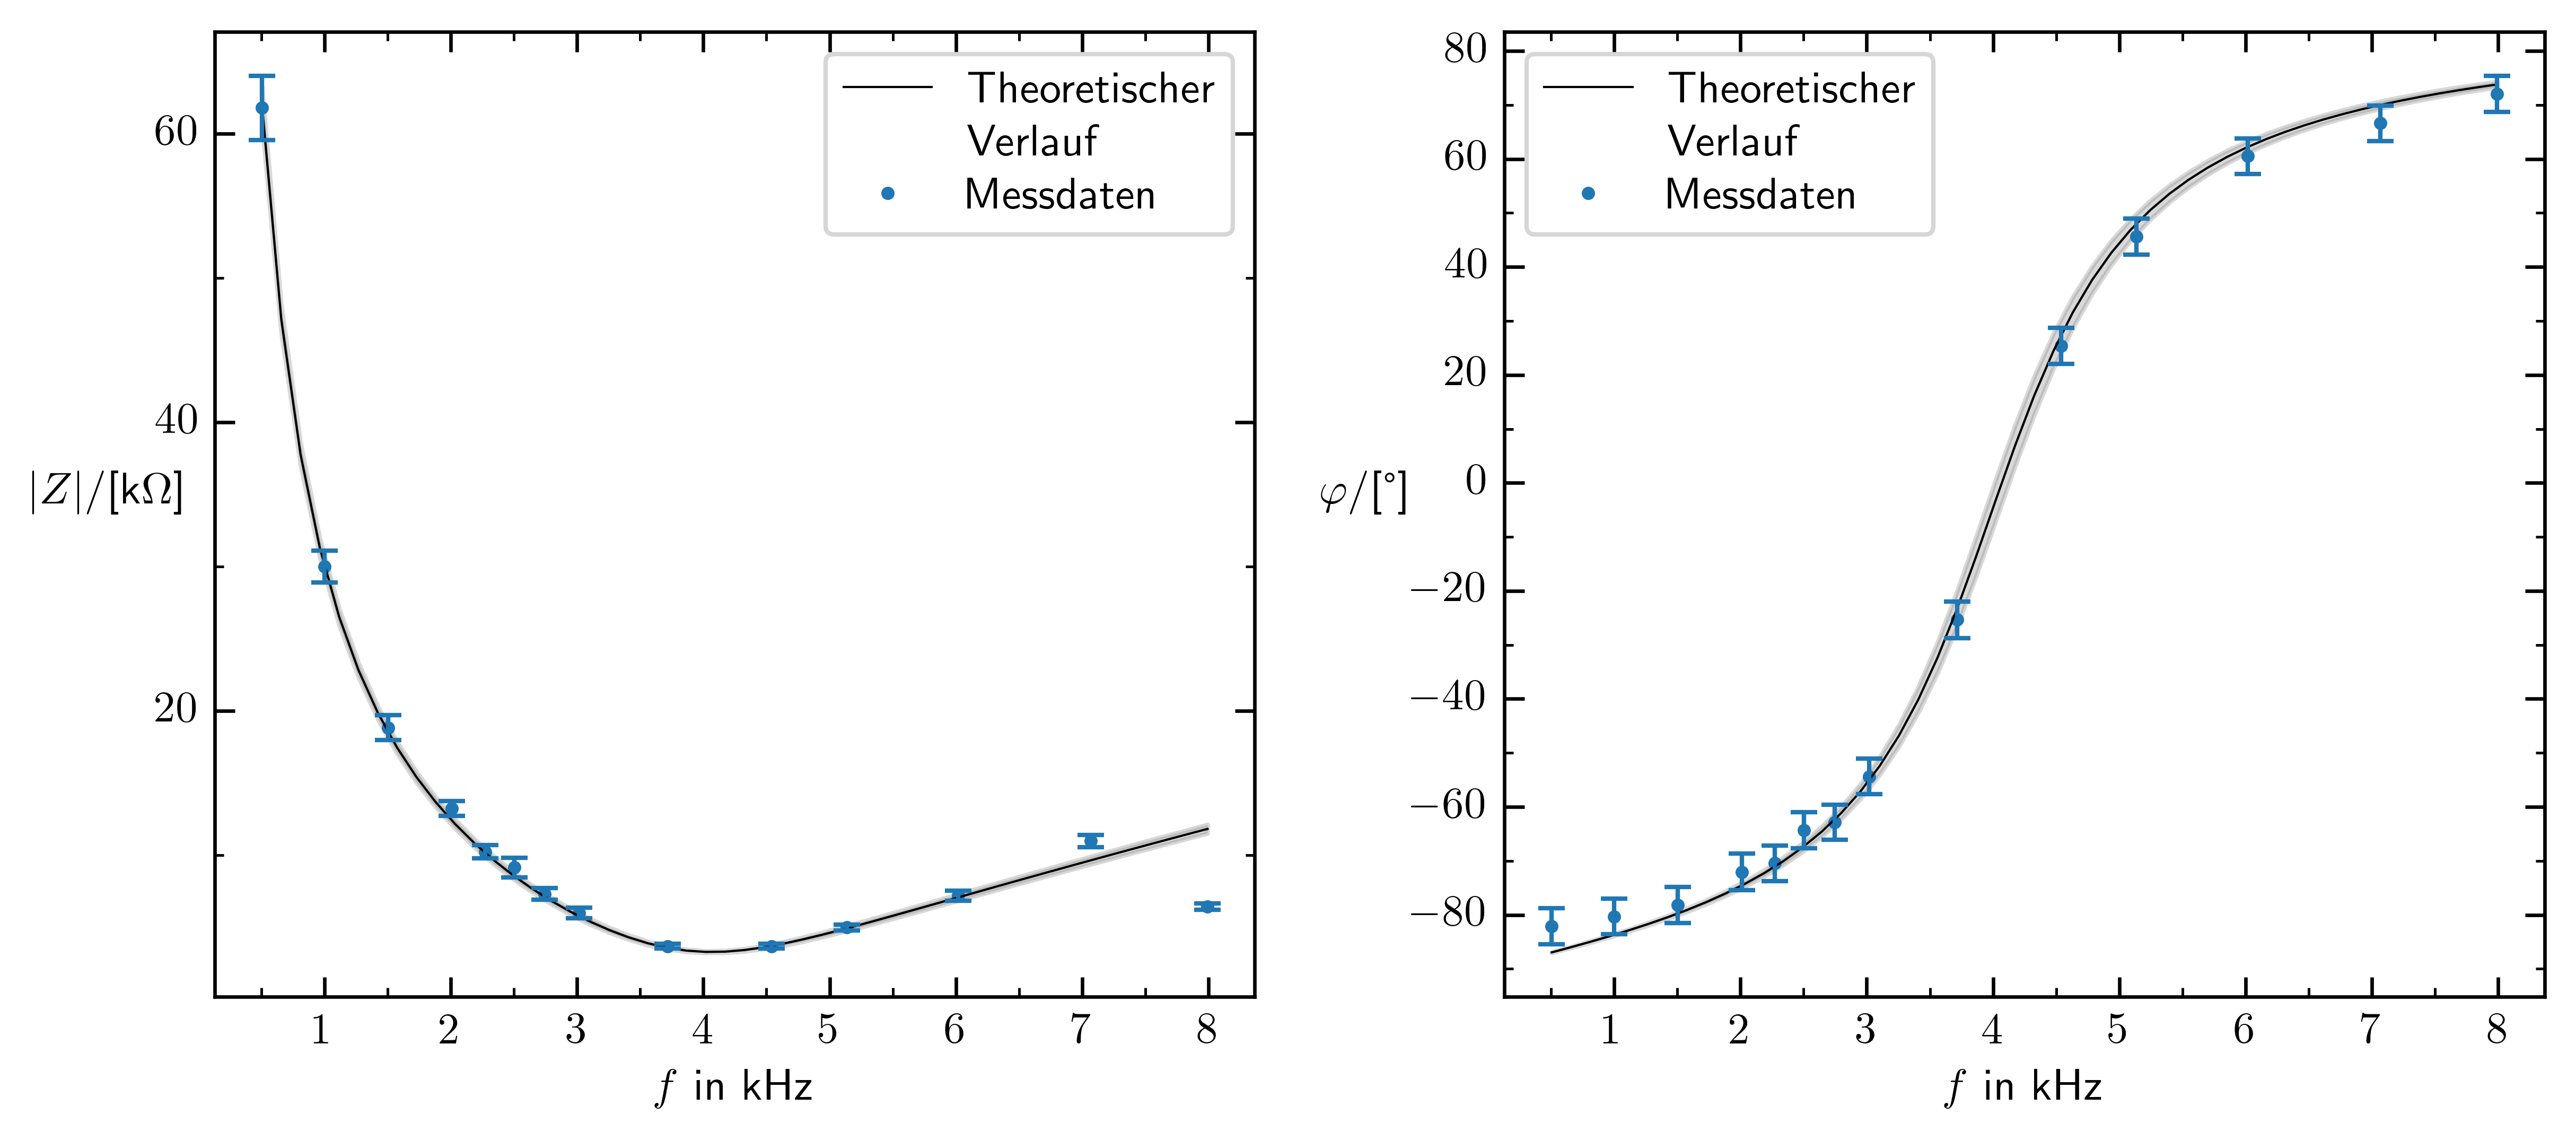

In [ ]:
arelips = df['a']**2+df['b']**2
np.mean(arelips), np.std(arelips)
f = np.linspace(df.loc[0,'f'],df.loc[len(df['f'])-1,'f'])*np.pi*2
tickp = TickProperties(SZX=False,SZY=False,\
                       xtick_step_major=1,\
                        xtick_step_minor=0.5,\
                            ytick_step_major=20,\
                                ytick_step_minor=10)
setup = Setup_Fig(name_of_plot='analog_reihe.pdf',tickp=tickp)
plot_dim = (-0.5, 60.5, 60.5, -0.5)
setup.fig_width= 24*cm
setup.fig_height=10*cm #29.1*cm
fig, ax = setup.return_fig(shape=(1,2),dots_per_inch=600)

# fig , ax = plt.subplots(1,2)

line01 = ax[0].plot(f/np.pi/2/1000,zreihe(f,0.3054,5.01/10**9,3.3*1000),linewidth=0.5,color='0')
ax[0].fill_between(f/np.pi/2/1000,zreihe(f,0.3054,5.01/10**9,3.3*1000)-2*zrstd(f,0.3054,5.01/10**9,3.3*1000),zreihe(f,0.3054,5.01/10**9,3.3*1000)+2*zrstd(f,0.3054,5.01/10**9,3.3*1000),alpha=0.3,interpolate=True,color='0.5')
line02 = ax[0].errorbar(df['f']/1000,zmode(df['R'],df['px'],df['py']),yerr=2*zstd(df['R'],df['px'],df['py']),barsabove=True,fmt='o',markersize=2,capsize=3,elinewidth=1)
# plt.plot(f/np.pi/2,zreihe(f,0.3054,5.01/10**9,3.3*1000)+2*zrstd(f,0.3054,5.01/10**9,3.3*1000))
ax[0].set_ylabel(r'$|Z|$/[k$\Omega$]',rotation=0,labelpad=10)
ax[0].set_xlabel(r'$f$ in kHz')
ax[0].legend([line01[0],line02[0]],[r'\,\\Theoretischer \\Verlauf',r'Messdaten'])
mid = len(df['f'])//2+1
end = len(df['f'])

line11 = ax[1].plot(f/np.pi/2/1000,phi_reihe(f,0.3054,5.01/10**9,3.3*1000),linewidth=0.5,color='0')
ax[1].fill_between(f/1000/np.pi/2,phi_reihe(f,0.3054,5.01/10**9,3.3*1000)-2*phirstd(f,0.3054,5.01/10**9,3.3*1000),phi_reihe(f,0.3054,5.01/10**9,3.3*1000)+2*phirstd(f,0.3054,5.01/10**9,3.3*1000),alpha=0.3,color='0.5')
f_ex, a , b = df.loc[0:mid,'f'], df.loc[0:mid,'a'], df.loc[0:mid,'b']
line12 = ax[1].errorbar(f_ex/1000,-phi(a,b),yerr=2*phi_std(a,b),barsabove=True,fmt='o',markersize=2,capsize=3,elinewidth=1)
f_ex2, a2 , b2 = df.loc[mid+1:end,'f'], df.loc[mid+1:end,'a'], df.loc[mid+1:end,'b']
ax[1].errorbar(f_ex2/1000,phi(a2,b2),yerr=2*phi_std(a2,b2),barsabove=True,fmt='o',markersize=2,capsize=3,color='tab:blue',elinewidth=1)
ax[1].yaxis.set_major_locator(plt.MultipleLocator(20))
ax[1].yaxis.set_minor_locator(plt.MultipleLocator(10))
ax[1].set_ylabel(r'$\varphi$/[°]',rotation=0,labelpad=10)
ax[1].set_xlabel(r'$f$ in kHz')
ax[1].legend([line11[0],line12[0]],[r'\,\\Theoretischer \\Verlauf',r'Messdaten'])
plt.subplots_adjust(wspace=0.24)
# ax[1].yaxis.set_major_formatter(plt.FuncFormatter(multiple_formatter()))
# plt.savefig("/home/christian/Documents/Praktikum/RE/pictures/"+setup.name_of_plot)
plt.show()

i:  24  end:  109


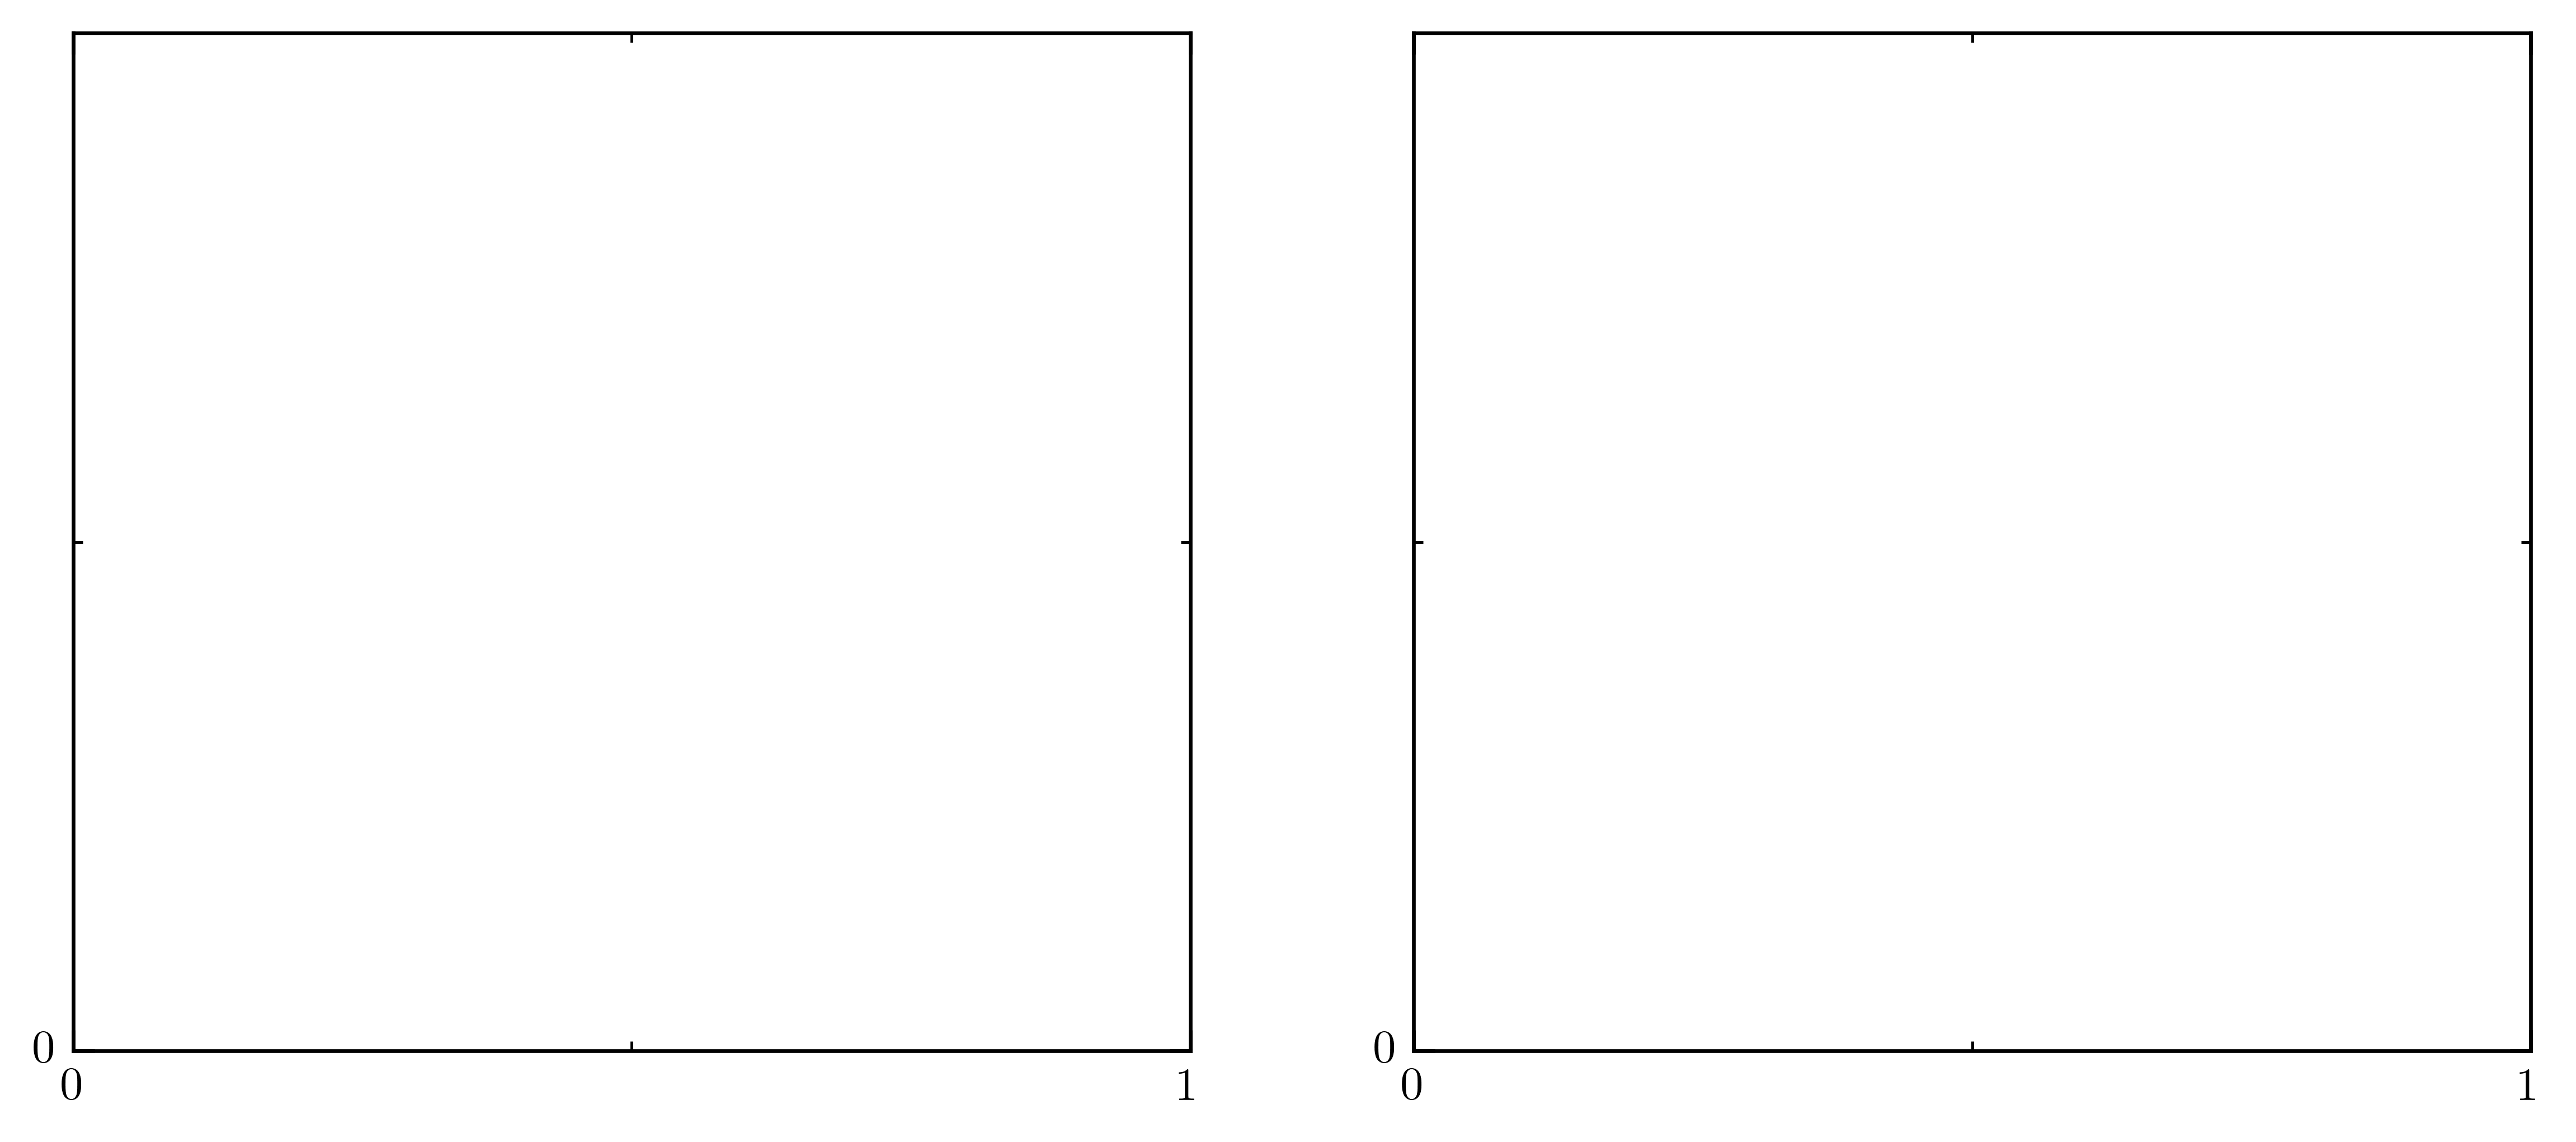

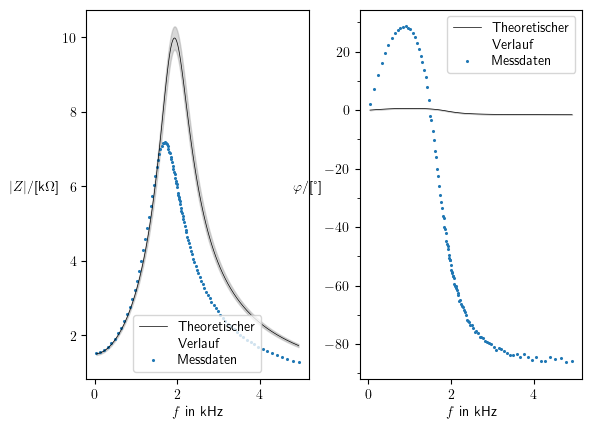

In [124]:
# df = pd.read_csv('Reihe_3.3K.csv',delimiter=';')
df = pd.read_csv('Parallel2_1.5K.csv',delimiter=';')
def angle(phi,*fields):
    end = len(phi)
    i = phi.loc[phi==0].index[0]
    phi.drop(index=i,inplace=True)
    m = phi.loc[i-30:i-1].min()
    j = phi.loc[phi==m].index[0]
    phi = phi.to_numpy()
    
    print('i: ',j,' end: ',end)
    phi[j:end] = -np.abs(phi[j:end])
    for field in fields:
        field.drop(index=i,inplace=True)
    return phi, *fields
phi_func = phi_par2
phi_err = phi_par2_std
z_func = zpar2
z_err = zpar2_std

# phi_func = phi_reihe
# phi_err = phirstd
# z_func = zreihe
# z_err = zrstd

f = df['Frequenz f / Hz']
omg = f*2*np.pi
z = df['Impedanz Z / k&W']
phi1 = df['Phasenverschiebung &j_1 / °']
phi2 = df['Phasenverschiebung &j_2 / °']
phi2, f, omg, z = angle(phi2,f, omg, z)
L, C, R = 0.3054, 22/10**9, 1.5*1000
msize = 1.5
# arelips = df['a']**2+df['b']**2
# np.mean(arelips), np.std(arelips)
# omg = np.linspace(df.loc[0,'f'],df.loc[len(f)-1,'f'])*np.pi*2
tickp = TickProperties(SZX=False,SZY=False,\
                       xtick_step_major=1,\
                        xtick_step_minor=0.5,\
                            ytick_step_major=2,\
                                ytick_step_minor=0.5)
setup = Setup_Fig(name_of_plot='digital_par2.pdf',tickp=tickp)
plot_dim = (-0.5, 60.5, 60.5, -0.5)
setup.fig_width= 24*cm
setup.fig_height=10*cm #29.1*cm
fig, ax = setup.return_fig(shape=(1,2),dots_per_inch=600)

fig , ax = plt.subplots(1,2)

line01 = ax[0].plot(f/1000,z_func(omg,L,C,R),linewidth=0.5,color='0')

ax[0].fill_between(f/1000,z_func(omg,L,C,R)-2*z_err(omg,L,C,R),z_func(omg,L,C,R)+2*z_err(omg,L,C,R),alpha=0.3,interpolate=True,color='0.5')
line02 = ax[0].scatter(f/1000,z,s=msize)
# line02 = ax[0].errorbar(f/1000,zmode(df['R'],df['px'],df['py']),yerr=2*zstd(df['R'],df['px'],df['py']),barsabove=True,fmt='o',markersize=2,capsize=3,elinewidth=1)
# plt.plot(omg/np.pi/2,zreihe(omg,L,C,R)+2*zrstd(omg,L,C,R))
ax[0].set_ylabel(r'$|Z|$/[k$\Omega$]',rotation=0,labelpad=20)
ax[0].set_xlabel(r'$f$ in kHz')
ax[0].legend([line01[0],line02],[r'\,\\Theoretischer \\Verlauf',r'Messdaten'])
mid = len(f)//2+1
end = len(f)

line11 = ax[1].plot(f/1000,phi_func(omg,L,C,R),linewidth=0.5,color='0')
ax[1].fill_between(f/1000,phi_func(omg,L,C,R)-2*phi_err(omg,L,C,R),phi_func(omg,L,C,R)+2*phi_err(omg,L,C,R),alpha=0.3,color='0.5')
# f_ex, a , b = df.loc[0:mid,'f'], df.loc[0:mid,'a'], df.loc[0:mid,'b']
line12 = ax[1].scatter(f/1000,phi2,s=msize)
# f_ex2, a2 , b2 = df.loc[mid+1:end,'f'], df.loc[mid+1:end,'a'], df.loc[mid+1:end,'b']
# ax[1].scatter(f_ex2/1000,phi1,color='tab:blue',s=msize)
ax[1].yaxis.set_major_locator(plt.MultipleLocator(20))
ax[1].yaxis.set_minor_locator(plt.MultipleLocator(10))
ax[1].set_ylabel(r'$\varphi$/[°]',rotation=0,labelpad=13)
ax[1].set_xlabel(r'$f$ in kHz')
ax[1].legend([line11[0],line12],[r'\,\\Theoretischer \\Verlauf',r'Messdaten'])
plt.subplots_adjust(wspace=0.23)
# ax[1].yaxis.set_major_formatter(plt.FuncFormatter(multiple_formatter()))
# plt.savefig("/home/christian/Documents/Praktikum/RE/pictures/"+setup.name_of_plot)
plt.show()

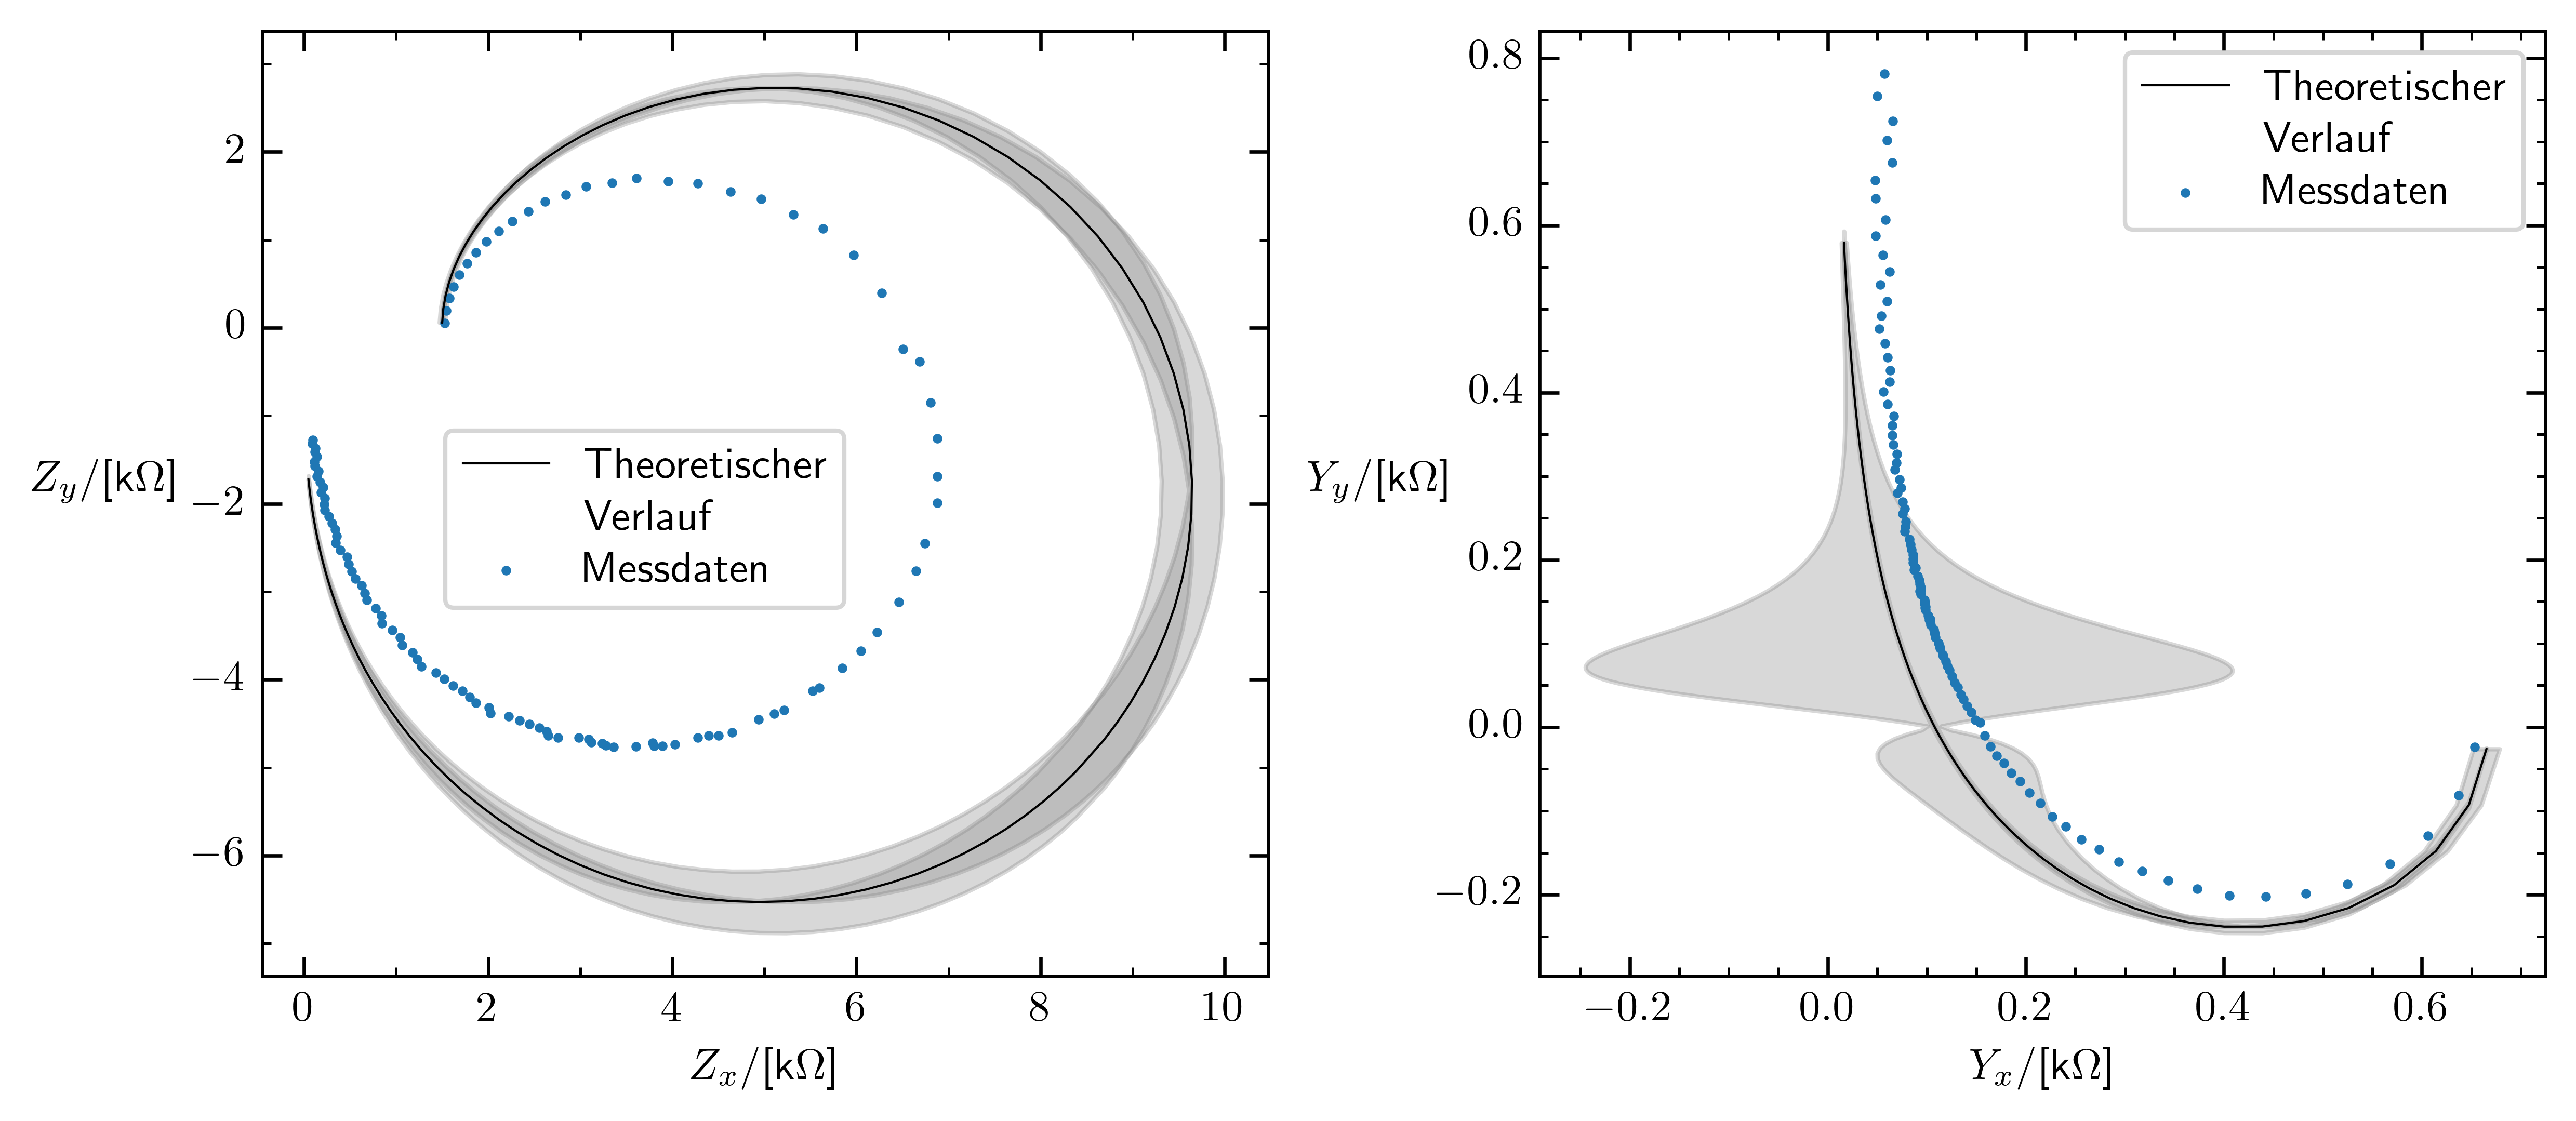

In [ ]:
tickp = TickProperties(SZX=False,SZY=False,\
                       xtick_step_major=2,\
                        xtick_step_minor=1,\
                            ytick_step_major=2,\
                                ytick_step_minor=1)
setup = Setup_Fig(name_of_plot='digital_par2_zpolar.pdf',tickp=tickp)
plot_dim = (-0.5, 60.5, 60.5, -0.5)
setup.fig_width= 24*cm
setup.fig_height=10*cm #29.1*cm
# phi_func = phi_par1
# phi_err = phi_par1_std
# z_func = zpar1
# z_err = zpar1_std
# phi2 = phi2/180*np.pi
# omg = np.linspace(omg[0],omg[len(omg)-1],2000)
fig, ax = setup.return_fig(shape=(1,2),dots_per_inch=600)
zx_t = z_func(omg,L,C,R)*np.cos(phi_func(omg,L,C,R))
zy_t = z_func(omg,L,C,R)*np.sin(phi_func(omg,L,C,R))
zx_err = np.sqrt((z_err(omg,L,C,R)*np.cos(phi_func(omg,L,C,R)))**2+(zy_t*phi_err(omg,L,C,R))**2)
zy_err = np.sqrt((z_err(omg,L,C,R)*np.sin(phi_func(omg,L,C,R)))**2+(zx_t*phi_err(omg,L,C,R))**2)
yx_t = 1/z_func(omg,L,C,R)*np.cos(-phi_func(omg,L,C,R))
yy_t = 1/z_func(omg,L,C,R)*np.sin(-phi_func(omg,L,C,R))
yx_err = np.sqrt((z_err(omg,L,C,R)*np.cos(phi_func(omg,L,C,R))/z_func(omg,L,C,R)**2)**2+(zy_t*phi_err(omg,L,C,R))**2)
yy_err = np.sqrt((z_err(omg,L,C,R)*np.sin(phi_func(omg,L,C,R))/z_func(omg,L,C,R)**2)**2+(yx_t*phi_err(omg,L,C,R))**2)
zx = z*np.cos(phi2)
zy = z*np.sin(phi2)
yx = 1/z*np.cos(-phi2)
yy = 1/z*np.sin(-phi2)


# fig , ax = plt.subplots(1,2)

line01 = ax[0].plot(zx_t,zy_t,linewidth=0.5,color='0')

ax[0].fill_between(zx_t,zy_t-2*zy_err,zy_t+2*zy_err,alpha=0.3,interpolate=True,color='0.5')
ax[0].fill_betweenx(zy_t,zx_t-2*zx_err,zx_t+2*zx_err,alpha=0.3,interpolate=True,color='0.5')
line02 = ax[0].scatter(zx,zy,s=msize)
# line02 = ax[0].errorbar(f/1000,zmode(df['R'],df['px'],df['py']),yerr=2*zstd(df['R'],df['px'],df['py']),barsabove=True,fmt='o',markersize=2,capsize=3,elinewidth=1)
# plt.plot(omg/np.pi/2,zreihe(omg,L,C,R)+2*zrstd(omg,L,C,R))
ax[0].set_ylabel(r'$Z_y$/[k$\Omega$]',rotation=0,labelpad=20)
ax[0].set_xlabel(r'$Z_x$/[k$\Omega$]')
ax[0].legend([line01[0],line02],[r'\,\\Theoretischer \\Verlauf',r'Messdaten'],bbox_to_anchor=(0.1, 0.1, 0.5, 0.5))
mid = len(f)//2+1
end = len(f)

line11 = ax[1].plot(yx_t,yy_t,linewidth=0.5,color='0')
ax[1].fill_between(yx_t,yy_t-2*yy_err,yy_t+2*yy_err,alpha=0.3,color='0.5')
ax[1].fill_betweenx(yy_t,yx_t-2*yx_err,yx_t+2*yx_err,alpha=0.3,color='0.5')
# f_ex, a , b = df.loc[0:mid,'f'], df.loc[0:mid,'a'], df.loc[0:mid,'b']
line12 = ax[1].scatter(yx,yy,s=msize)
# f_ex2, a2 , b2 = df.loc[mid+1:end,'f'], df.loc[mid+1:end,'a'], df.loc[mid+1:end,'b']
# ax[1].scatter(f_ex2/1000,phi1,color='tab:blue',s=msize)
ax[1].yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax[1].yaxis.set_minor_locator(plt.MultipleLocator(0.05))
ax[1].xaxis.set_major_locator(plt.MultipleLocator(0.2))
ax[1].xaxis.set_minor_locator(plt.MultipleLocator(0.05))
ax[1].set_ylabel(r'$Y_y$/[k$\Omega$]',rotation=0,labelpad=13)
ax[1].set_xlabel(r'$Y_x$/[k$\Omega$]')
ax[1].legend([line11[0],line12],[r'\,\\Theoretischer \\Verlauf',r'Messdaten'])#,bbox_to_anchor=(0.3, 0.25, 0.5, 0.5))
plt.subplots_adjust(wspace=0.27)
# ax[1].yaxis.set_major_formatter(plt.FuncFormatter(multiple_formatter()))
# plt.savefig("/home/christian/Documents/Praktikum/RE/pictures/"+setup.name_of_plot)
plt.show()